In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

# 1. Data Loading & Preprocessing

In [2]:
# Load dataset
df = pd.read_csv('metadata.csv')

# We only need discharge cycles to measure Capacity fade
df_discharge = df[df['type'] == 'discharge'].copy()

# Sort by battery and start_time (assuming test_id is chronological)
df_discharge = df_discharge.sort_values(by=['battery_id', 'test_id'])

# Calculate Cycle number for each battery
df_discharge['Cycle'] = df_discharge.groupby('battery_id').cumcount() + 1

# Convert Capacity to numbers (invalid parsing will be set as NaN)
df_discharge['Capacity'] = pd.to_numeric(df_discharge['Capacity'], errors='coerce')
df_discharge = df_discharge.dropna(subset=['Capacity'])

def calculate_rul(group):
    # Grab the battery's capacity at Cycle 1
    initial_capacity = group['Capacity'].iloc[0]
    
    # Define EOL as 70% of THIS specific battery's initial capacity
    eol_threshold = initial_capacity * 0.70
    
    # If the battery reaches the threshold, find the cycle it crosses EOL
    eol_cycles = group[group['Capacity'] < eol_threshold]['Cycle']
    
    if not eol_cycles.empty:
        eol_cycle = eol_cycles.iloc[0]
        group['RUL'] = eol_cycle - group['Cycle']
        # For cycles past EOL, we can set RUL to 0 or negative. Let's clip at 0.
        group['RUL'] = group['RUL'].apply(lambda x: max(0, x))
    else:
        # If it never reached EOL in the dataset, RUL is unknown
        group['RUL'] = group['Cycle'].max() - group['Cycle']
        
    # Define State for this battery specifically: 1 (Healthy), 0 (Degraded)
    group['State'] = (group['Capacity'] >= eol_threshold).astype(int)
    
    return group

# Apply the dynamic calculation to all batteries
df_discharge = df_discharge.groupby('battery_id').apply(calculate_rul).reset_index(drop=True)
# Drop unnecessary columns
df_discharge = df_discharge.drop(columns=['Re', 'Rct'])
print(f"Total Discharge Samples: {len(df_discharge)}")
df_discharge.head()

Total Discharge Samples: 2769


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Cycle,RUL,State
0,discharge,[2.0080e+03 4.0000e+00 2.0000e+00 1.5000e+01 2...,24,B0005,1,5122,05122.csv,1.856487,1,161,1
1,discharge,[2.0080e+03 4.0000e+00 2.0000e+00 1.9000e+01 4...,24,B0005,3,5124,05124.csv,1.846327,2,160,1
2,discharge,[2.008e+03 4.000e+00 3.000e+00 0.000e+00 1.000...,24,B0005,5,5126,05126.csv,1.835349,3,159,1
3,discharge,[2008. 4. 3. 4. 16. ...,24,B0005,7,5128,05128.csv,1.835263,4,158,1
4,discharge,[2008. 4. 3. 8. 33. ...,24,B0005,9,5130,05130.csv,1.834646,5,157,1


# 2. Exploratory Data Analysis

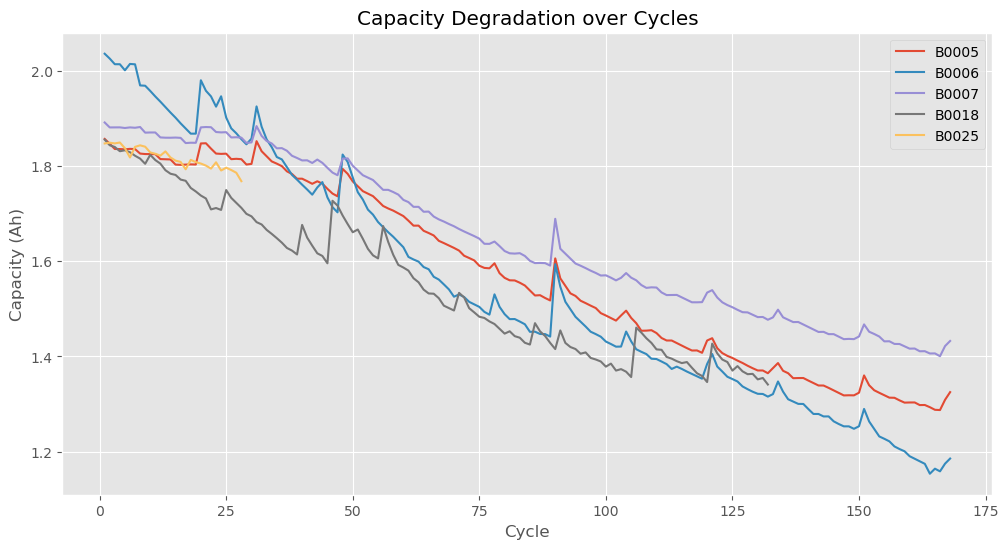

In [3]:
plt.figure(figsize=(12, 6))
sample_batteries = df_discharge['battery_id'].unique()[:5] # Plot first 5 batteries

for batt in sample_batteries:
    subset = df_discharge[df_discharge['battery_id'] == batt]
    plt.plot(subset['Cycle'], subset['Capacity'], label=batt)

plt.title('Capacity Degradation over Cycles')
plt.xlabel('Cycle')
plt.ylabel('Capacity (Ah)')
plt.legend()
plt.show()

# 3. Train / Test Split

In [4]:
batteries = df_discharge['battery_id'].unique()
train_batts, test_batts = train_test_split(batteries, test_size=0.3, random_state=42)

train_df = df_discharge[df_discharge['battery_id'].isin(train_batts)].copy()
test_df = df_discharge[df_discharge['battery_id'].isin(test_batts)].copy()

print(f"Training Batteries: {len(train_batts)} | Testing Batteries: {len(test_batts)}")
print(f"Training Samples: {len(train_df)} | Testing Samples: {len(test_df)}")

Training Batteries: 23 | Testing Batteries: 11
Training Samples: 1833 | Testing Samples: 936


# 4. Time-Series Forecasting (LSTM)

In [5]:
# Prepare sequences for LSTM
def create_sequences(data, seq_length=10):
    xs = []
    ys = []
    col_name = data.columns[0]
    for i in range(len(data)-seq_length):
        x = data.iloc[i:(i+seq_length)][col_name].values
        y = data.iloc[i+seq_length][col_name]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 10
X_train_lstm, y_train_lstm = [], []
X_test_lstm, y_test_lstm = [], []

# Normalize Capacity
# ... (rest of the cell stays the same)

scaler = MinMaxScaler()
train_df['Capacity_Scaled'] = scaler.fit_transform(train_df[['Capacity']])
test_df['Capacity_Scaled'] = scaler.transform(test_df[['Capacity']])

for batt in train_batts:
    batt_data = train_df[train_df['battery_id'] == batt]
    if len(batt_data) > SEQ_LENGTH:
        X, y = create_sequences(batt_data[['Capacity_Scaled']], SEQ_LENGTH)
        X_train_lstm.append(X)
        y_train_lstm.append(y)

for batt in test_batts:
    batt_data = test_df[test_df['battery_id'] == batt]
    if len(batt_data) > SEQ_LENGTH:
        X, y = create_sequences(batt_data[['Capacity_Scaled']], SEQ_LENGTH)
        X_test_lstm.append(X)
        y_test_lstm.append(y)

X_train_lstm = np.vstack(X_train_lstm)
y_train_lstm = np.concatenate(y_train_lstm)
X_test_lstm = np.vstack(X_test_lstm)
y_test_lstm = np.concatenate(y_test_lstm)

# Reshape for LSTM [samples, time steps, features]
X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], X_train_lstm.shape[1], 1))
X_test_lstm = X_test_lstm.reshape((X_test_lstm.shape[0], X_test_lstm.shape[1], 1))

print(f"X_train shape: {X_train_lstm.shape}, y_train shape: {y_train_lstm.shape}")


X_train shape: (1609, 10, 1), y_train shape: (1609,)


In [6]:
# Build LSTM Model
model = Sequential()
model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(SEQ_LENGTH, 1)))
model.add(LSTM(50, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# Train Model
history = model.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - loss: 0.1253 - val_loss: 0.0172
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0094 - val_loss: 0.0037
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0075 - val_loss: 0.0027
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0069 - val_loss: 0.0023
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0065 - val_loss: 0.0021
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0064 - val_loss: 0.0023
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0065 - val_loss: 0.0033
Epoch 8/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0063 - val_loss: 0.0020
Epoch 9/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0062 - val_loss: 0.0022
Epoch 10/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0061 - val_loss: 0.0022
Epoch 11/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0059 - val_loss: 0.0020
Epoch 12/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step
LSTM Test RMSE: 0.1995


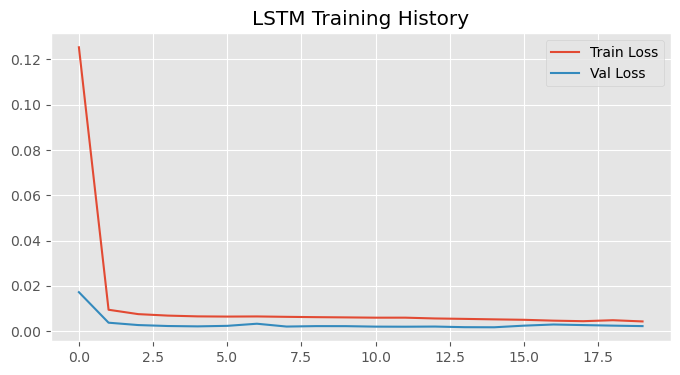

In [7]:
# Evaluate LSTM
y_pred_scaled = model.predict(X_test_lstm)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_unscaled = scaler.inverse_transform(y_test_lstm.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(y_test_unscaled, y_pred))
print(f"LSTM Test RMSE: {rmse:.4f}")

# Plotting loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training History')
plt.legend()
plt.show()

# 5. State Classification (Healthy vs Degraded)

In [8]:
# Features for Classification
# We will use Cycle, ambient_temperature as features to predict State
features = ['Cycle', 'ambient_temperature']
X_train_clf = train_df[features].fillna(0)
y_train_clf = train_df['State']

X_test_clf = test_df[features].fillna(0)
y_test_clf = test_df['State']

# Scale features
clf_scaler = StandardScaler()
X_train_clf_scaled = clf_scaler.fit_transform(X_train_clf)
X_test_clf_scaled = clf_scaler.transform(X_test_clf)

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       133
           1       0.86      1.00      0.92       803

    accuracy                           0.86       936
   macro avg       0.43      0.50      0.46       936
weighted avg       0.74      0.86      0.79       936

--- Support Vector Machine ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       133
           1       0.86      1.00      0.92       803

    accuracy                           0.86       936
   macro avg       0.43      0.50      0.46       936
weighted avg       0.74      0.86      0.79       936

--- K-Nearest Neighbors ---
              precision    recall  f1-score   support

           0       0.70      0.62      0.66       133
           1       0.94      0.96      0.95       803

    accuracy                           0.91       936
   macro avg       0.82      0.79      0.

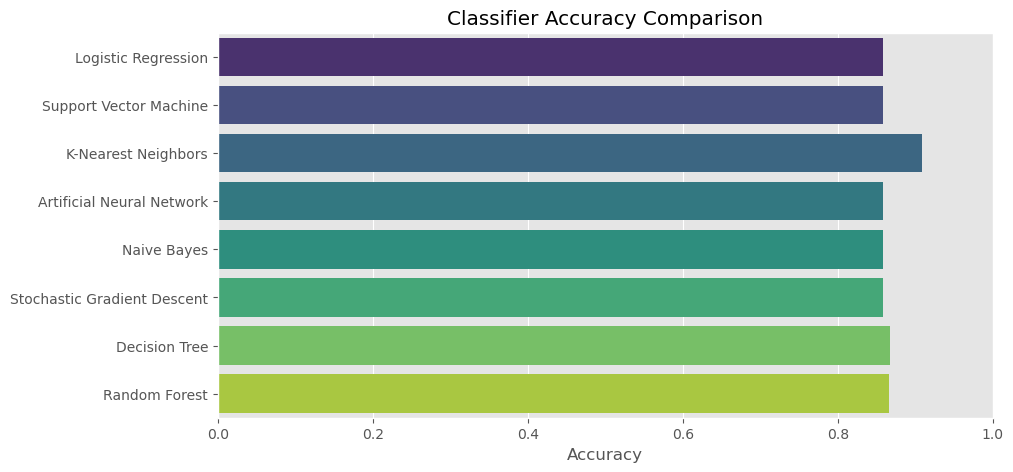

In [9]:
# Initialize Classifiers
from sklearn.ensemble import RandomForestClassifier
classifiers = {
    "Logistic Regression": LogisticRegression(),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Artificial Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Stochastic Gradient Descent": SGDClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth = 15, min_samples_leaf = 1, min_samples_split = 2,random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=15, min_samples_leaf = 1, min_samples_split = 2, random_state=42)
}

results = {}

for name, clf in classifiers.items():
    clf.fit(X_train_clf_scaled, y_train_clf)
    y_pred = clf.predict(X_test_clf_scaled)
    acc = accuracy_score(y_test_clf, y_pred)
    results[name] = acc
    print(f"--- {name} ---")
    print(classification_report(y_test_clf, y_pred))

# Plot accuracy comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=list(results.values()), y=list(results.keys()), palette='viridis')
plt.title('Classifier Accuracy Comparison')
plt.xlabel('Accuracy')
plt.xlim(0, 1)
plt.show()


# 6. Handling Imbalanced Data: SMOTE & Random Forest

In [10]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Apply SMOTE to the training data to artificially balance the classes
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_clf_scaled, y_train_clf)

print(f"Original Training Distribution:\n{y_train_clf.value_counts().to_string()}")
print(f"\nNew SMOTE Training Distribution:\n{y_train_smote.value_counts().to_string()}")
print("-" * 40)

# 2. Train Random Forest on the newly balanced data
rf_smote = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=1, min_samples_split=2, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

# 3. Test the model on the UNTOUCHED test data
y_pred_smote = rf_smote.predict(X_test_clf_scaled)

print("\n--- Random Forest + SMOTE ---")
print(classification_report(y_test_clf, y_pred_smote))

Original Training Distribution:
State
1    1628
0     205

New SMOTE Training Distribution:
State
1    1628
0    1628
----------------------------------------

--- Random Forest + SMOTE ---
              precision    recall  f1-score   support

           0       0.42      0.77      0.54       133
           1       0.96      0.82      0.88       803

    accuracy                           0.81       936
   macro avg       0.69      0.79      0.71       936
weighted avg       0.88      0.81      0.83       936



# 7. Hyperparameter Optimization (GridSearchCV)

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# ==========================================
# 1. Hyperparameter Tuning for KNN
# ==========================================
print("--- Tuning K-Nearest Neighbors ---")
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2] # 1 = Manhattan distance, 2 = Euclidean distance
}

# We use scoring='f1' to balance Precision and Recall
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='f1', n_jobs=-1)
knn_grid.fit(X_train_clf_scaled, y_train_clf) 

print(f"Best KNN Parameters: {knn_grid.best_params_}")
y_pred_knn_best = knn_grid.predict(X_test_clf_scaled)
print(classification_report(y_test_clf, y_pred_knn_best))
print("="*50)


# ==========================================
# 2. Hyperparameter Tuning for RF + SMOTE
# ==========================================
print("\n--- Tuning Random Forest + SMOTE ---")
# CRITICAL: We use ImbPipeline so SMOTE is applied safely inside each Cross-Validation fold!
rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

rf_params = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [5, 10, 15],
    'rf__min_samples_split': [2, 5, 10]
}

# We use scoring='recall' because our #1 goal for RF is catching dead batteries safely!
rf_grid = GridSearchCV(rf_pipeline, rf_params, cv=5, scoring='recall', n_jobs=-1)
rf_grid.fit(X_train_clf_scaled, y_train_clf)

print(f"Best RF Parameters: {rf_grid.best_params_}")
y_pred_rf_best = rf_grid.predict(X_test_clf_scaled)
print(classification_report(y_test_clf, y_pred_rf_best))

--- Tuning K-Nearest Neighbors ---
Best KNN Parameters: {'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}
              precision    recall  f1-score   support

           0       0.68      0.53      0.60       133
           1       0.93      0.96      0.94       803

    accuracy                           0.90       936
   macro avg       0.80      0.75      0.77       936
weighted avg       0.89      0.90      0.89       936


--- Tuning Random Forest + SMOTE ---
Best RF Parameters: {'rf__max_depth': 15, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
              precision    recall  f1-score   support

           0       0.42      0.77      0.54       133
           1       0.96      0.82      0.88       803

    accuracy                           0.81       936
   macro avg       0.69      0.79      0.71       936
weighted avg       0.88      0.81      0.83       936



# 8. Final Forecasting: XGBoost Regression

--- XGBoost Classifier ---
              precision    recall  f1-score   support

           0       0.75      0.02      0.04       133
           1       0.86      1.00      0.92       803

    accuracy                           0.86       936
   macro avg       0.81      0.51      0.48       936
weighted avg       0.84      0.86      0.80       936

XGBoost RUL Regression - RMSE: 37.39, MAE: 29.59


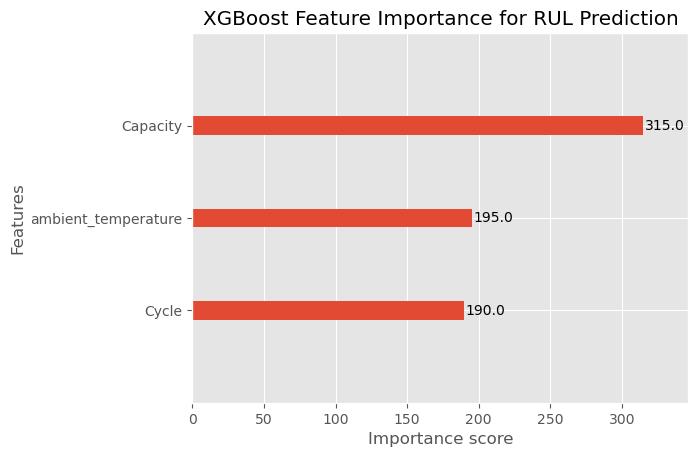

Actual cycles left: 161, Predicted cycles left: 77


In [12]:
# XGBoost Classification (State)
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train_clf_scaled, y_train_clf)
y_pred_xgb_clf = xgb_clf.predict(X_test_clf_scaled)
print("--- XGBoost Classifier ---")
print(classification_report(y_test_clf, y_pred_xgb_clf))

# XGBoost Regression (RUL)
# Features for RUL
features_rul = ['Cycle', 'Capacity', 'ambient_temperature']
X_train_rul = train_df[features_rul]
y_train_rul = train_df['RUL']

X_test_rul = test_df[features_rul]
y_test_rul = test_df['RUL']

xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', learning_rate=0.01, max_depth=3, n_estimators=100, random_state=42)
xgb_reg.fit(X_train_rul, y_train_rul)
y_pred_rul = xgb_reg.predict(X_test_rul)

rmse_xgb = np.sqrt(mean_squared_error(y_test_rul, y_pred_rul))
mae_xgb = mean_absolute_error(y_test_rul, y_pred_rul)
print(f"XGBoost RUL Regression - RMSE: {rmse_xgb:.2f}, MAE: {mae_xgb:.2f}")

# Feature importance for RUL
xgb.plot_importance(xgb_reg)
plt.title('XGBoost Feature Importance for RUL Prediction')
plt.show()

print(f"Actual cycles left: {y_test_rul.iloc[0]}, Predicted cycles left: {y_pred_rul[0]:.0f}")

# 8. Optimizing XGBoost for Minimum Error

In [13]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("--- Tuning XGBoost RUL Regression ---")
print("Training dozens of models... Please wait a moment...")

# 1. Define the base XGBoost Regressor
xgb_reg_base = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# 2. Define the grid of parameters to search
xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

# 3. Setup GridSearchCV 
# (Note: Scikit-learn uses 'neg_root_mean_squared_error' because it always tries to MAXIMIZE the score. 
# By making the error negative, maximizing it means pushing the error closer to 0!)
xgb_grid = GridSearchCV(xgb_reg_base, xgb_params, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)

# 4. Train all 27 combinations using Cross-Validation
xgb_grid.fit(X_train_rul, y_train_rul)

print(f"\nBest XGBoost Parameters: {xgb_grid.best_params_}")

# 5. Test the optimized model on the unseen test data
y_pred_xgb_best = xgb_grid.predict(X_test_rul)

rmse_xgb_best = np.sqrt(mean_squared_error(y_test_rul, y_pred_xgb_best))
mae_xgb_best = mean_absolute_error(y_test_rul, y_pred_xgb_best)

print(f"Optimized XGBoost RUL - RMSE: {rmse_xgb_best:.2f}, MAE: {mae_xgb_best:.2f}")
print(f"Actual cycles left (First Test Battery): {y_test_rul.iloc[0]}, Predicted cycles left: {y_pred_xgb_best[0]:.0f}")

--- Tuning XGBoost RUL Regression ---
Training dozens of models... Please wait a moment...

Best XGBoost Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Optimized XGBoost RUL - RMSE: 37.39, MAE: 29.59
Actual cycles left (First Test Battery): 161, Predicted cycles left: 77
